In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from feature_module import *
from processing_module import *

In [2]:
# Generate a synthetic dataset to test:
# List with the standard amino acids
standard_amino_acids = ['C', 'M', 'V', 'L', 'I', 'W', 'Y', 'F', 'H', 'T',
                        'N', 'Q', 'K', 'R', 'D', 'E', 'A', 'S', 'G', 'P']

# Generate random sequences of 300 aa
np.random.seed(42)
num_sequences = 5000
synth_sequences = [''.join(np.random.choice(standard_amino_acids, size=300))\
                   for i in range(num_sequences)]

# Generate random values for the metric (no correlation with the sequence)
synth_metric = np.random.uniform(size=num_sequences)

In [3]:
# To calculate some features, we will use a typical grouping of amino acids
aromatic_aa = ['W', 'Y', 'F']

In [4]:
# Let's test the feature functionalities:
# Get the composition of aromatic amino acids
aromatic_comp = group_composition(synth_sequences, aromatic_aa)

# Get the adjacency pairs coefficient for aromatic amino acids
aromatic_C_adj = adjacent_pairs_coefficient(synth_sequences, aromatic_aa)

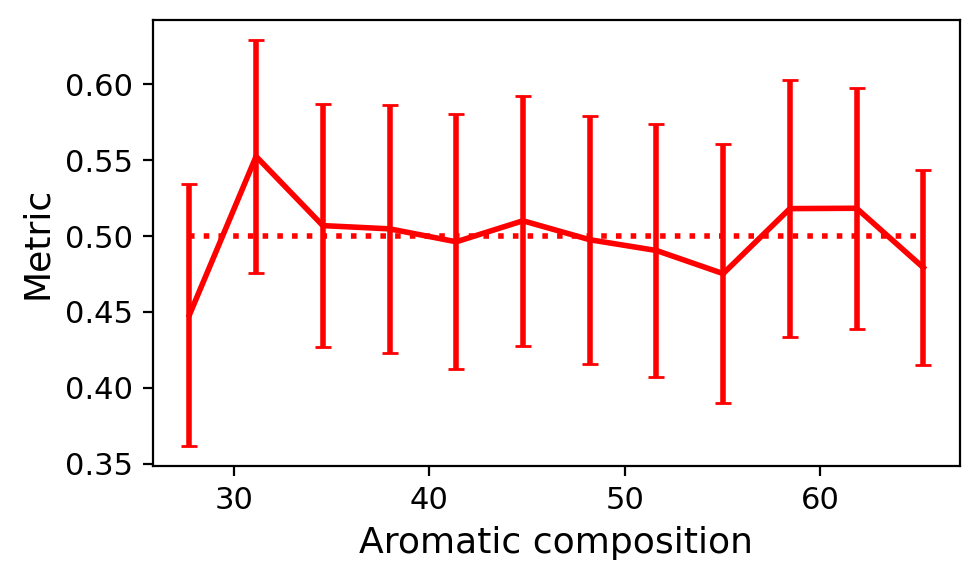

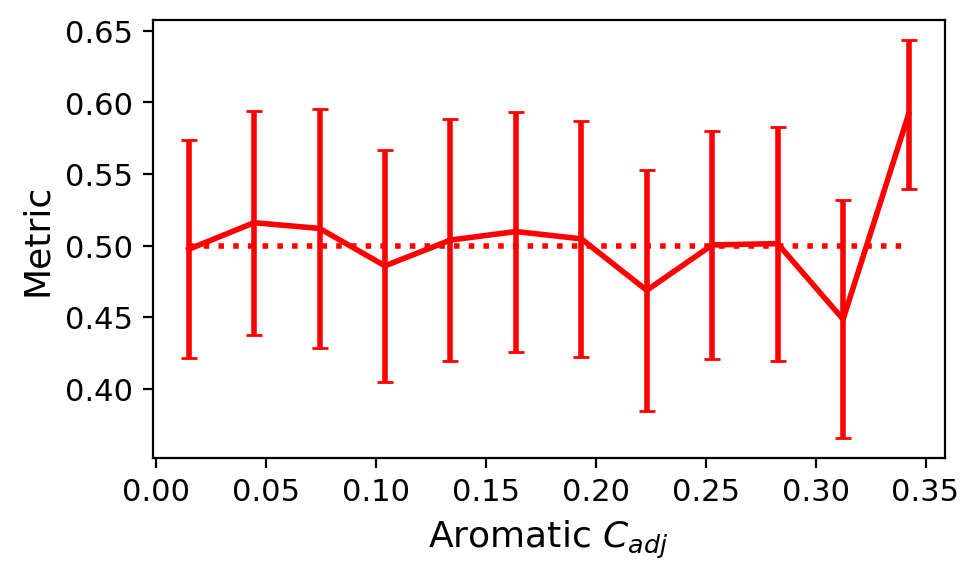

In [5]:
# Let's test some of the processing functionalities:
# Single feature plot for our features
# Aromatic composition
plot_single_feature_metric(aromatic_comp, synth_metric, xlabel='Aromatic composition')
# Aromatic adjacent pairs
plot_single_feature_metric(aromatic_C_adj, synth_metric, xlabel=r'Aromatic $C_{adj}$')

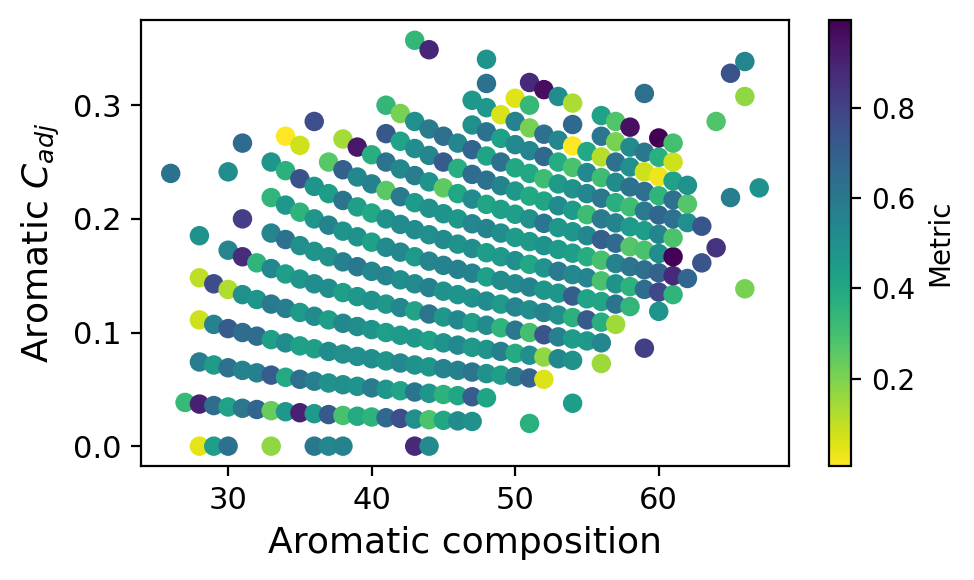

In [6]:
# Now, let's plot the two features in a single grid
plot_2D_feature_grid(aromatic_comp, aromatic_C_adj, synth_metric, cutoff=0,
                    xlabel='Aromatic composition', ylabel=r'Aromatic $C_{adj}$')

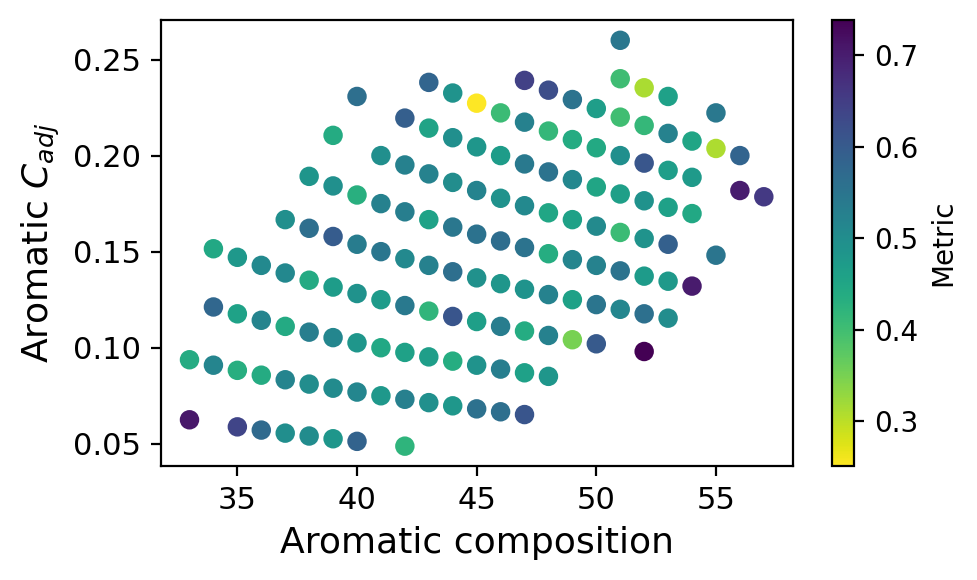

In [7]:
# We can change the cutoff
plot_2D_feature_grid(aromatic_comp, aromatic_C_adj, synth_metric, cutoff=10,
                    xlabel='Aromatic composition', ylabel=r'Aromatic $C_{adj}$')

In [8]:
# We can get the partial correlations
feature_pair_partial_correlation(aromatic_comp, aromatic_C_adj, synth_metric, cutoff=0)

,Feature 1,Feature 2,Metric
Feature 1,1.000000,0.336178,-0.018756
Feature 2,0.336178,1.000000,-0.036325
Metric,-0.018756,-0.036325,1.000000


As expected, there is no partial correlation between the features and the synthetic metric.

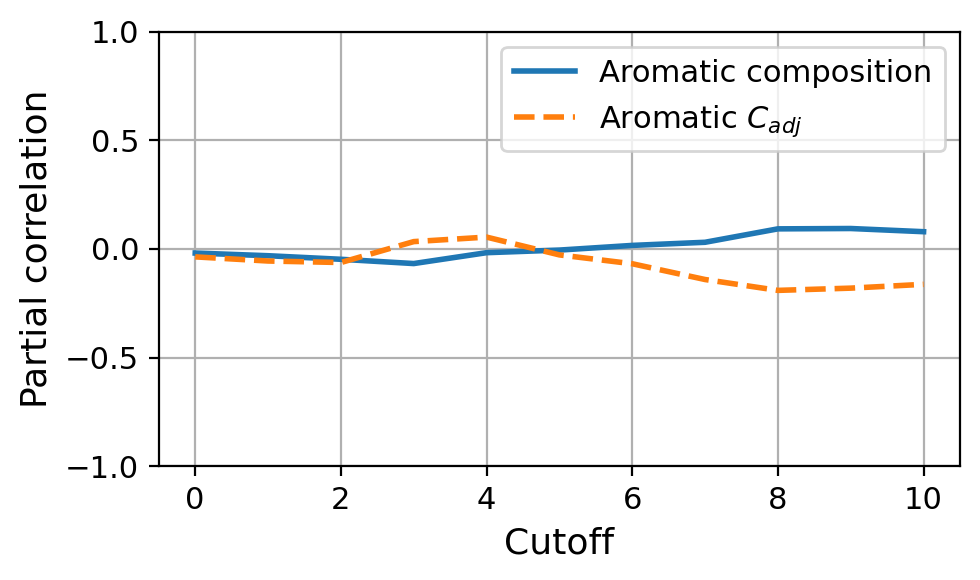

In [9]:
# Finally, we can run the analysis for multiple cutoff values
plot_partial_correlation_vs_cutoff(
    aromatic_comp, aromatic_C_adj, synth_metric, 
    cutoff_values=np.arange(11), feature_1_name='Aromatic composition',
    feature_2_name=r'Aromatic $C_{adj}$')